# 04 — Feature Selection + Final Pipeline (LOCAL)
## WavSent-MTL · Tasks 1.24–1.35

**Pipeline steps covered (Steps 6–16):**
- Step 6:  MI ranking on Kotekar training set → top 10 features
- Step 7:  SHAP filter (lightweight LSTM, 10 seeds) → top 6-7 features
- Step 8:  Save selected_features.json for kotekar and kaggle
- Steps 9-16: For BOTH datasets:
  - Build final feature DataFrame (drop NaN, warmup rows)
  - 70/15/15 temporal split (no shuffling)
  - Fit MinMaxScaler on train only → transform all splits
  - Build sliding windows [5 x n_features]
  - Generate clf + reg targets
  - Normalize reg targets (StandardScaler, fit on train only)
  - Check class imbalance → save class_weights.json
  - Save all .npy arrays

**Hard rules:**
- Feature selection done ONCE on Kotekar training set only
- Same technical features transferred to Kaggle (no re-selection)
- Scaler NEVER fit on val or test
- No shuffling at any point
- Test set untouched until notebook 09

In [1]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from config.config import CONFIG

print('CONFIG loaded.')
print('Candidate features:', CONFIG['candidate_features'])
print('MI top-k:', CONFIG['mi_top_k'], '| SHAP top-k:', CONFIG['shap_top_k'])

CONFIG loaded.
Candidate features: ['Close_d', 'Open_d', 'High_d', 'Low_d', 'Volume_d', 'RSI_14', 'MACD', 'BB_width', 'ROC_5', 'EMA_9', 'ATR_14', 'OBV', 'STOCH_K', 'WILLIAMS_R', 'CCI_20']
MI top-k: 10 | SHAP top-k: 7


## Load Kotekar Featured Data

In [2]:
kotekar_dir = os.path.join(project_root, CONFIG['kotekar_processed_dir'])
kotekar_featured = os.path.join(kotekar_dir, 'featured_data.csv')

df_kot = pd.read_csv(kotekar_featured)
df_kot['Date'] = pd.to_datetime(df_kot['Date'])
df_kot = df_kot.sort_values('Date').reset_index(drop=True)

print(f'Kotekar featured_data: {df_kot.shape}')
print(f'Date range: {df_kot["Date"].min().date()} -> {df_kot["Date"].max().date()}')
print(f'Columns: {df_kot.columns.tolist()}')
df_kot.head(3)

Kotekar featured_data: (1067, 18)
Date range: 2020-01-28 -> 2024-05-31
Columns: ['Date', 'Close_d', 'Open_d', 'High_d', 'Low_d', 'Volume_d', 'RSI_14', 'MACD', 'BB_width', 'ROC_5', 'EMA_9', 'ATR_14', 'OBV', 'STOCH_K', 'WILLIAMS_R', 'CCI_20', 'Close', 'polarity_mean']


,Date,Close_d,Open_d,High_d,Low_d,Volume_d,RSI_14,MACD,BB_width,ROC_5,EMA_9,ATR_14,OBV,STOCH_K,WILLIAMS_R,CCI_20,Close,polarity_mean
0,2020-01-28,12128.942120,12179.583646,12211.800802,12100.981238,448585.144027,55.059502,-9.004343,0.034965,-0.014603,12181.789496,104.789974,2.118666e+06,11.673879,-88.326121,-51.239948,12055.7998,0.0
1,2020-01-29,12117.376391,12144.364772,12180.980704,12083.482078,497186.119867,43.574256,-14.204085,0.035547,-0.308704,12168.906875,101.801766,1.621480e+06,9.923573,-90.076427,-62.933336,12129.5000,0.0
2,2020-01-30,12000.663046,12091.507541,12103.893674,11987.173224,603938.879238,27.939158,-27.426553,0.038466,-1.671894,12135.258109,104.487641,1.017541e+06,3.080836,-96.919164,-123.511254,12035.7998,0.0


## Task 1.24 — Temporal Split (Kotekar)

In [3]:
from src.data.windows import temporal_split

train_df, val_df, test_df = temporal_split(df_kot)

# Verify temporal ordering
assert train_df['Date'].max() < val_df['Date'].min(), 'Train/val date overlap!'
assert val_df['Date'].max() < test_df['Date'].min(), 'Val/test date overlap!'

print(f'Train: {len(train_df)} rows | {train_df["Date"].min().date()} -> {train_df["Date"].max().date()}')
print(f'Val:   {len(val_df)} rows | {val_df["Date"].min().date()} -> {val_df["Date"].max().date()}')
print(f'Test:  {len(test_df)} rows | {test_df["Date"].min().date()} -> {test_df["Date"].max().date()}')
print('Temporal ordering: OK')

Split: Train=746 | Val=160 | Test=161
Train: 746 rows | 2020-01-28 -> 2023-01-30
Val:   160 rows | 2023-01-31 -> 2023-09-22
Test:  161 rows | 2023-09-25 -> 2024-05-31
Temporal ordering: OK


## Task 1.25 — MI Ranking on Kotekar Training Set

In [4]:
from src.data.windows import generate_targets
from src.data.feature_selection import mi_ranking
from sklearn.feature_selection import mutual_info_classif

CANDIDATE_FEATURES = CONFIG['candidate_features']

# Generate targets on training set (raw Close for direction)
# Note: targets use raw Close (not denoised) per DECISIONS.md
# Close column contains raw close price in featured_data.csv
y_clf_train_full, _ = generate_targets(train_df['Close'].values)

# MI uses training features (no windowing — just 2D)
# Align: target at position i = row i+window in train_df
# For MI we use train_df[CANDIDATE_FEATURES] rows 0..-window aligned to y
window = CONFIG['window_size']
X_train_mi = train_df[CANDIDATE_FEATURES].values[:len(y_clf_train_full)]

# Run MI ranking
top10 = mi_ranking(X_train_mi, y_clf_train_full, CANDIDATE_FEATURES)

print('Top 10 by MI score:')
mi_scores = mutual_info_classif(
    X_train_mi, y_clf_train_full,
    random_state=CONFIG['feature_selection_seed']
)
mi_series = pd.Series(mi_scores, index=CANDIDATE_FEATURES).sort_values(ascending=False)
print(mi_series.head(10).to_string())
print(f'\nTop 10 selected: {top10}')

d:\WavSent-MTL\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Top 10 by MI score:
RSI_14        0.026231
Volume_d      0.024512
WILLIAMS_R    0.023373
STOCH_K       0.023373
Close_d       0.019322
Open_d        0.019055
EMA_9         0.016820
CCI_20        0.015461
MACD          0.004484
High_d        0.001015

Top 10 selected: ['RSI_14', 'Volume_d', 'WILLIAMS_R', 'STOCH_K', 'Close_d', 'Open_d', 'EMA_9', 'CCI_20', 'MACD', 'High_d']


## MI Score Bar Plot

Saved: results/figures/feature_selection/mi_scores.png


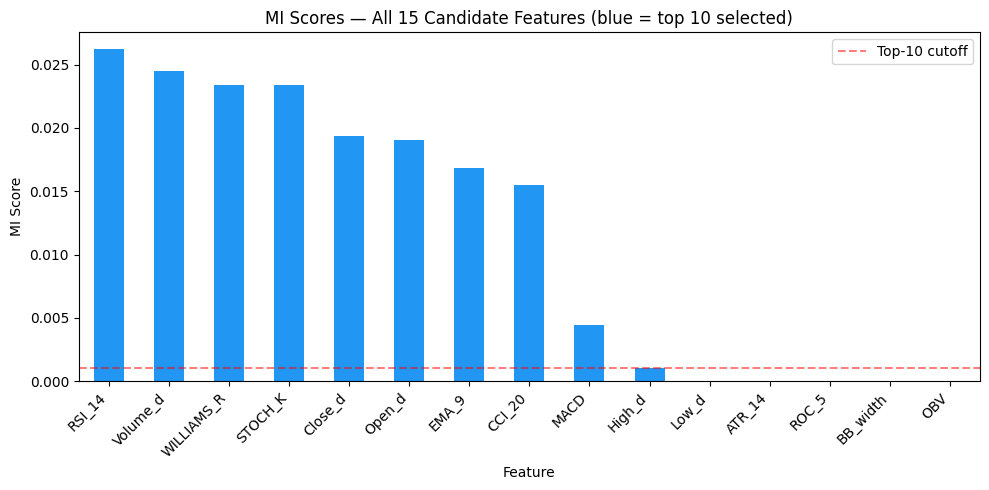

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3' if f in top10 else '#BDBDBD' for f in mi_series.index]
mi_series.plot(kind='bar', ax=ax, color=colors)
ax.set_title('MI Scores — All 15 Candidate Features (blue = top 10 selected)')
ax.set_xlabel('Feature')
ax.set_ylabel('MI Score')
ax.axhline(mi_series.iloc[9], color='red', linestyle='--', alpha=0.5, label='Top-10 cutoff')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

fig_dir = os.path.join(project_root, CONFIG['figures_dir'], 'feature_selection')
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, 'mi_scores.png'), dpi=150)
print('Saved: results/figures/feature_selection/mi_scores.png')
plt.show()

## Tasks 1.26-1.27 — SHAP Filter

Train lightweight LSTM (32 units, 10 seeds) on top-10 features, compute SHAP, keep top 6-7.

> **Note:** This cell takes a few minutes (10 seeds x 20 epochs each). The SHAP computation is on a small model.

In [6]:
from src.data.preprocessor import apply_scaler
from src.data.feature_selection import run_feature_selection

# Scale training data (top-10 only) for SHAP LSTM
# Fit scaler temporarily on train top-10 (full scaler fit happens in Step 12)
from sklearn.preprocessing import MinMaxScaler
top10_idx = [CANDIDATE_FEATURES.index(f) for f in top10]
X_top10_train = X_train_mi[:, top10_idx]

temp_scaler = MinMaxScaler()
X_top10_scaled = temp_scaler.fit_transform(X_top10_train)

print('Running SHAP-based feature selection...')
print(f'Input shape: {X_top10_scaled.shape}')
print(f'Settings: {CONFIG["feature_selection_runs"]} seeds, {CONFIG["feature_selection_units"]} units')

selected_tech, top10_names = run_feature_selection(
    X_top10_scaled,
    y_clf_train_full,
    feature_names=top10,
    top_n_final=CONFIG['shap_top_k']
)

print(f'\nSHAP-selected technical features ({len(selected_tech)}): {selected_tech}')

Running SHAP-based feature selection...
Input shape: (741, 10)
Settings: 10 seeds, 32 units

SHAP-selected technical features (7): ['WILLIAMS_R', 'STOCH_K', 'MACD', 'RSI_14', 'CCI_20', 'EMA_9', 'Volume_d']


## Task 1.28-1.30 — Save selected_features.json

In [7]:
# Kotekar: technical features + polarity_mean
selected_kotekar = selected_tech + ['polarity_mean']
# Kaggle: same technical features + polarity_mean + polarity_max
selected_kaggle  = selected_tech + ['polarity_mean', 'polarity_max']

print(f'Kotekar selected ({len(selected_kotekar)}): {selected_kotekar}')
print(f'Kaggle selected  ({len(selected_kaggle)}): {selected_kaggle}')

# Save kotekar
kotekar_feat_path = os.path.join(kotekar_dir, 'selected_features.json')
with open(kotekar_feat_path, 'w') as f:
    json.dump(selected_kotekar, f, indent=2)
print(f'Saved: {kotekar_feat_path}')

# Save kaggle
kaggle_dir = os.path.join(project_root, CONFIG['kaggle_processed_dir'])
kaggle_feat_path = os.path.join(kaggle_dir, 'selected_features.json')
with open(kaggle_feat_path, 'w') as f:
    json.dump(selected_kaggle, f, indent=2)
print(f'Saved: {kaggle_feat_path}')

Kotekar selected (8): ['WILLIAMS_R', 'STOCH_K', 'MACD', 'RSI_14', 'CCI_20', 'EMA_9', 'Volume_d', 'polarity_mean']
Kaggle selected  (9): ['WILLIAMS_R', 'STOCH_K', 'MACD', 'RSI_14', 'CCI_20', 'EMA_9', 'Volume_d', 'polarity_mean', 'polarity_max']
Saved: d:/WavSent-MTL/data/processed/kotekar/selected_features.json
Saved: d:/WavSent-MTL/data/processed/kaggle/selected_features.json


## Pipeline Steps 9-16 Helper

In [8]:
from src.data.windows import create_windows, generate_targets, check_class_imbalance
from src.data.preprocessor import apply_scaler, apply_reg_scaler


def run_full_pipeline(df_full: pd.DataFrame,
                      selected_features: list,
                      out_dir: str,
                      dataset_name: str):
    """Run Steps 9-16 for one dataset: split, scale, window, targets, save.

    Args:
        df_full:           Full featured_data DataFrame with Date + features + Close.
        selected_features: Final list of feature column names.
        out_dir:           Directory to save all output files.
        dataset_name:      'kotekar' or 'kaggle' (for logging).
    """
    print(f'\n{"=" * 55}')
    print(f'Pipeline Steps 9-16: {dataset_name}')
    print(f'{"=" * 55}')

    # --- Step 9: Build final feature DataFrame ---
    keep_cols = ['Date'] + selected_features + ['Close']
    df = df_full[keep_cols].dropna(subset=selected_features).reset_index(drop=True)
    print(f'Step 9  | Shape after NaN drop: {df.shape}')

    # --- Step 10: Verify no missing values ---
    nan_total = df[selected_features].isnull().sum().sum()
    assert nan_total == 0, f'Found {nan_total} NaN in selected features'
    print(f'Step 10 | NaN check: {nan_total}  OK')

    # --- Step 11: Temporal split 70/15/15 ---
    train_df, val_df, test_df = temporal_split(df)
    assert train_df['Date'].max() < val_df['Date'].min()
    assert val_df['Date'].max() < test_df['Date'].min()
    print(f'Step 11 | Train={len(train_df)} Val={len(val_df)} Test={len(test_df)}  OK')

    # --- Step 12: Fit MinMaxScaler on train ONLY ---
    scaler_path = os.path.join(out_dir, 'scaler.pkl')
    train_raw = train_df[selected_features].values
    val_raw   = val_df[selected_features].values
    test_raw  = test_df[selected_features].values

    train_scaled, val_scaled, test_scaled, scaler = apply_scaler(
        train_raw, val_raw, test_raw, scaler_path
    )
    assert train_scaled.max() <= 1.0 and train_scaled.min() >= 0.0, 'Scaler range error'
    print(f'Step 12 | Scaler fit on train. train range [{train_scaled.min():.3f}, {train_scaled.max():.3f}]  OK')

    # --- Step 13: Sliding windows ---
    window = CONFIG['window_size']
    X_train = create_windows(train_scaled, window)
    X_val   = create_windows(val_scaled, window)
    X_test  = create_windows(test_scaled, window)
    print(f'Step 13 | X_train={X_train.shape} X_val={X_val.shape} X_test={X_test.shape}')

    # --- Step 14: Generate targets ---
    # Use raw Close prices (not denoised, not scaled)
    y_clf_train, y_reg_train = generate_targets(train_df['Close'].values, window)
    y_clf_val,   y_reg_val   = generate_targets(val_df['Close'].values, window)
    y_clf_test,  y_reg_test  = generate_targets(test_df['Close'].values, window)

    # Normalize regression targets (StandardScaler, fit on train only)
    reg_scaler_path = os.path.join(out_dir, 'reg_scaler.pkl')
    y_reg_train, y_reg_val, y_reg_test, _ = apply_reg_scaler(
        y_reg_train, y_reg_val, y_reg_test, reg_scaler_path
    )

    # Verify shapes align
    assert len(X_train) == len(y_clf_train) == len(y_reg_train), 'Train shape mismatch'
    assert len(X_val)   == len(y_clf_val)   == len(y_reg_val),   'Val shape mismatch'
    assert len(X_test)  == len(y_clf_test)  == len(y_reg_test),  'Test shape mismatch'
    print(f'Step 14 | Targets: clf in {{0,1}} unique={set(np.unique(y_clf_train))}  OK')

    # --- Step 15: Class imbalance check ---
    cw_path = os.path.join(out_dir, 'class_weights.json')
    cw = check_class_imbalance(y_clf_train, save_path=cw_path)
    print(f'Step 15 | Class weights: {cw}')

    # --- Step 16: Save all arrays ---
    arrays = {
        'X_train':      X_train,
        'X_val':        X_val,
        'X_test':       X_test,
        'y_clf_train':  y_clf_train,
        'y_clf_val':    y_clf_val,
        'y_clf_test':   y_clf_test,
        'y_reg_train':  y_reg_train,
        'y_reg_val':    y_reg_val,
        'y_reg_test':   y_reg_test,
    }
    for name, arr in arrays.items():
        np.save(os.path.join(out_dir, f'{name}.npy'), arr)
    print(f'Step 16 | Saved {len(arrays)} arrays to {out_dir}')

    print(f'\nFinal shapes ({dataset_name}):')
    print(f'  X_train:     {X_train.shape}  float32')
    print(f'  X_val:       {X_val.shape}  float32')
    print(f'  X_test:      {X_test.shape}  float32')
    print(f'  y_clf_train: {y_clf_train.shape}  int32')
    print(f'  y_reg_train: {y_reg_train.shape}  float32')

    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_clf_train': y_clf_train, 'y_clf_val': y_clf_val, 'y_clf_test': y_clf_test,
        'y_reg_train': y_reg_train, 'y_reg_val': y_reg_val, 'y_reg_test': y_reg_test,
    }

## Task 1.31 — Full Pipeline for Kotekar

In [9]:
kotekar_arrays = run_full_pipeline(
    df_full=df_kot,
    selected_features=selected_kotekar,
    out_dir=kotekar_dir,
    dataset_name='kotekar'
)


Pipeline Steps 9-16: kotekar
Step 9  | Shape after NaN drop: (1067, 10)
Step 10 | NaN check: 0  OK
Split: Train=746 | Val=160 | Test=161
Step 11 | Train=746 Val=160 Test=161  OK
Step 12 | Scaler fit on train. train range [0.000, 1.000]  OK
Step 13 | X_train=(741, 5, 8) X_val=(155, 5, 8) X_test=(156, 5, 8)
Step 14 | Targets: clf in {0,1} unique={np.int32(0), np.int32(1)}  OK
Up: 54.7% | Down: 45.3% | Ratio: 1.21
Class weights saved to d:/WavSent-MTL/data/processed/kotekar/class_weights.json: None
Step 15 | Class weights: None
Step 16 | Saved 9 arrays to d:/WavSent-MTL/data/processed/kotekar/

Final shapes (kotekar):
  X_train:     (741, 5, 8)  float32
  X_val:       (155, 5, 8)  float32
  X_test:      (156, 5, 8)  float32
  y_clf_train: (741,)  int32
  y_reg_train: (741,)  float32


## Task 1.32 — Full Pipeline for Kaggle

In [10]:
kaggle_featured = os.path.join(project_root, CONFIG['kaggle_processed_dir'], 'featured_data.csv')

df_kag = pd.read_csv(kaggle_featured)
df_kag['Date'] = pd.to_datetime(df_kag['Date'])
df_kag = df_kag.sort_values('Date').reset_index(drop=True)

print(f'Kaggle featured_data: {df_kag.shape}')

kaggle_arrays = run_full_pipeline(
    df_full=df_kag,
    selected_features=selected_kaggle,
    out_dir=kaggle_dir,
    dataset_name='kaggle'
)

Kaggle featured_data: (1794, 19)

Pipeline Steps 9-16: kaggle
Step 9  | Shape after NaN drop: (1794, 11)
Step 10 | NaN check: 0  OK
Split: Train=1255 | Val=269 | Test=270
Step 11 | Train=1255 Val=269 Test=270  OK
Step 12 | Scaler fit on train. train range [0.000, 1.000]  OK
Step 13 | X_train=(1250, 5, 9) X_val=(264, 5, 9) X_test=(265, 5, 9)
Step 14 | Targets: clf in {0,1} unique={np.int32(0), np.int32(1)}  OK
Up: 54.9% | Down: 45.1% | Ratio: 1.22
Class weights saved to d:/WavSent-MTL/data/processed/kaggle/class_weights.json: None
Step 15 | Class weights: None
Step 16 | Saved 9 arrays to d:/WavSent-MTL/data/processed/kaggle/

Final shapes (kaggle):
  X_train:     (1250, 5, 9)  float32
  X_val:       (264, 5, 9)  float32
  X_test:      (265, 5, 9)  float32
  y_clf_train: (1250,)  int32
  y_reg_train: (1250,)  float32


## Task 1.33 — Verify Array Shapes Match Expected

In [11]:
n_kotekar_feat = len(selected_kotekar)
n_kaggle_feat  = len(selected_kaggle)

print('=== Kotekar Shapes ===')
kot = kotekar_arrays
print(f'X_train:     {kot["X_train"].shape}  (expected ~730, 5, {n_kotekar_feat})')
print(f'X_val:       {kot["X_val"].shape}  (expected ~155, 5, {n_kotekar_feat})')
print(f'X_test:      {kot["X_test"].shape}  (expected ~155, 5, {n_kotekar_feat})')

# Dimension checks
assert kot['X_train'].shape[1] == CONFIG['window_size'], 'Window size mismatch (kotekar)'
assert kot['X_train'].shape[2] == n_kotekar_feat, f'Feature count mismatch (kotekar): {kot["X_train"].shape[2]} vs {n_kotekar_feat}'
assert set(np.unique(kot['y_clf_train'])).issubset({0, 1}), 'clf labels not binary'
print('Kotekar shape checks: OK')

print()
print('=== Kaggle Shapes ===')
kag = kaggle_arrays
print(f'X_train:     {kag["X_train"].shape}  (expected ~1230, 5, {n_kaggle_feat})')
print(f'X_val:       {kag["X_val"].shape}  (expected ~260, 5, {n_kaggle_feat})')
print(f'X_test:      {kag["X_test"].shape}  (expected ~260, 5, {n_kaggle_feat})')

assert kag['X_train'].shape[1] == CONFIG['window_size'], 'Window size mismatch (kaggle)'
assert kag['X_train'].shape[2] == n_kaggle_feat, f'Feature count mismatch (kaggle)'
assert set(np.unique(kag['y_clf_train'])).issubset({0, 1}), 'Kaggle clf labels not binary'
print('Kaggle shape checks: OK')

print()
print('All shape verifications PASSED  OK')

=== Kotekar Shapes ===
X_train:     (741, 5, 8)  (expected ~730, 5, 8)
X_val:       (155, 5, 8)  (expected ~155, 5, 8)
X_test:      (156, 5, 8)  (expected ~155, 5, 8)
Kotekar shape checks: OK

=== Kaggle Shapes ===
X_train:     (1250, 5, 9)  (expected ~1230, 5, 9)
X_val:       (264, 5, 9)  (expected ~260, 5, 9)
X_test:      (265, 5, 9)  (expected ~260, 5, 9)
Kaggle shape checks: OK

All shape verifications PASSED  OK


## Reload Arrays from Disk and Spot-Check

In [12]:
# Reload and confirm round-trip
X_train_reload = np.load(os.path.join(kotekar_dir, 'X_train.npy'))
y_clf_reload   = np.load(os.path.join(kotekar_dir, 'y_clf_train.npy'))
y_reg_reload   = np.load(os.path.join(kotekar_dir, 'y_reg_train.npy'))

assert X_train_reload.shape == kot['X_train'].shape, 'Reload shape mismatch'
assert np.allclose(X_train_reload, kot['X_train']), 'Reload value mismatch'
print(f'X_train reload: {X_train_reload.shape}  dtype={X_train_reload.dtype}  OK')
print(f'y_clf range:    min={y_clf_reload.min()}  max={y_clf_reload.max()}  OK')
print(f'y_reg range:    min={y_reg_reload.min():.4f}  max={y_reg_reload.max():.4f}  OK')
print(f'y_reg abs max:  {np.abs(y_reg_reload).max():.2f} (should be < 10.0 for standardized)')

X_train reload: (741, 5, 8)  dtype=float32  OK
y_clf range:    min=0  max=1  OK
y_reg range:    min=-9.1732  max=6.1156  OK
y_reg abs max:  9.17 (should be < 10.0 for standardized)


## Summary

In [13]:
print('=' * 55)
print('Notebook 04 -- Feature Selection + Pipeline: COMPLETE')
print('=' * 55)
print()
print('Feature Selection:')
print(f'  MI top-10:         {top10}')
print(f'  SHAP top selected: {selected_tech}')
print(f'  Kotekar features:  {selected_kotekar}')
print(f'  Kaggle features:   {selected_kaggle}')
print()
print('Kotekar arrays:')
print(f'  X_train: {kot["X_train"].shape}  X_val: {kot["X_val"].shape}  X_test: {kot["X_test"].shape}')
print()
print('Kaggle arrays:')
print(f'  X_train: {kag["X_train"].shape}  X_val: {kag["X_val"].shape}  X_test: {kag["X_test"].shape}')
print()
print('Files saved:')
print(f'  {kotekar_dir}/selected_features.json')
print(f'  {kotekar_dir}/class_weights.json')
print(f'  {kotekar_dir}/scaler.pkl  +  reg_scaler.pkl')
print(f'  {kotekar_dir}/X_train.npy  ...  y_reg_test.npy  (9 arrays)')
print(f'  {kaggle_dir}/... (same structure)')
print()
print('Next: push to GitHub, then run notebook 05 on Kaggle GPU')

Notebook 04 -- Feature Selection + Pipeline: COMPLETE

Feature Selection:
  MI top-10:         ['RSI_14', 'Volume_d', 'WILLIAMS_R', 'STOCH_K', 'Close_d', 'Open_d', 'EMA_9', 'CCI_20', 'MACD', 'High_d']
  SHAP top selected: ['WILLIAMS_R', 'STOCH_K', 'MACD', 'RSI_14', 'CCI_20', 'EMA_9', 'Volume_d']
  Kotekar features:  ['WILLIAMS_R', 'STOCH_K', 'MACD', 'RSI_14', 'CCI_20', 'EMA_9', 'Volume_d', 'polarity_mean']
  Kaggle features:   ['WILLIAMS_R', 'STOCH_K', 'MACD', 'RSI_14', 'CCI_20', 'EMA_9', 'Volume_d', 'polarity_mean', 'polarity_max']

Kotekar arrays:
  X_train: (741, 5, 8)  X_val: (155, 5, 8)  X_test: (156, 5, 8)

Kaggle arrays:
  X_train: (1250, 5, 9)  X_val: (264, 5, 9)  X_test: (265, 5, 9)

Files saved:
  d:/WavSent-MTL/data/processed/kotekar//selected_features.json
  d:/WavSent-MTL/data/processed/kotekar//class_weights.json
  d:/WavSent-MTL/data/processed/kotekar//scaler.pkl  +  reg_scaler.pkl
  d:/WavSent-MTL/data/processed/kotekar//X_train.npy  ...  y_reg_test.npy  (9 arrays)
  d: